# Задание 1. Знакомство с данными и EDA

## 1. Выбор датасета

In [1]:
#Работа будет происходить с датасетом Spotify_modified.csv, который
#содержит метаданные различных треков с платформы
#искусственно были добавлены выбросы, дубликаты и пропуски
import numpy as np
import pandas as pd


data = pd.read_csv("data/Spotify_modified.csv")
data.head()

,index,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73.0,230666,False,0.676,0.4610,...,-6.746,0.0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55.0,149610,False,0.420,0.1660,...,NaN,1.0,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57.0,210826,False,0.438,0.3590,...,-9.734,1.0,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71.0,201933,False,0.266,0.0596,...,-18.515,1.0,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82.0,198853,False,0.618,0.4430,...,-9.681,1.0,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [2]:
# import random

# # Загрузка данных
# data = pd.read_csv("data/Spotify.csv")

# # 1. Добавление дубликатов (5% от общего количества строк)
# n_duplicates = int(len(data) * 0.05)
# duplicate_indices = np.random.choice(data.index, n_duplicates, replace=False)
# duplicates = data.loc[duplicate_indices].copy()
# data = pd.concat([data, duplicates], ignore_index=True)

# # 2. Добавление пропусков (3% от общего количества ячеек)
# n_missing = int(data.size * 0.03)
# # Определим колонки, в которые можно добавлять пропуски
# missing_columns = ['artists', 'album_name', 'track_name', 'popularity', 'danceability', 
#                    'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness',
#                    'instrumentalness', 'liveness', 'valence', 'tempo', 'track_genre']

# # Генерируем случайные индексы для пропусков
# missing_indices = np.random.choice(data.index, n_missing, replace=True)
# missing_columns_sample = np.random.choice(missing_columns, n_missing, replace=True)

# # Добавляем пропуски
# for i in range(n_missing):
#     data.loc[missing_indices[i], missing_columns_sample[i]] = np.nan

# # 3. Добавление выбросов в числовые колонки
# numeric_columns = ['popularity', 'duration_ms', 'danceability', 'energy', 'key', 
#                    'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness',
#                    'liveness', 'valence', 'tempo']

# # Добавим выбросы в 2% от общего количества строк
# n_outliers = int(len(data) * 0.02)
# outlier_indices = np.random.choice(data.index, n_outliers, replace=False)

# for idx in outlier_indices:
#     # Выбираем случайную числовую колонку
#     column = np.random.choice(numeric_columns)
    
#     # Для разных колонок разные типы выбросов
#     if column in ['danceability', 'energy', 'acousticness', 'liveness', 'valence']:
#         # Эти значения обычно от 0 до 1, сделаем выбросы > 1 или < 0
#         data.loc[idx, column] = np.random.choice([-0.5, 1.5, 2.0])
#     elif column == 'popularity':
#         # Популярность от 0 до 100
#         data.loc[idx, column] = np.random.choice([-50, 150, 200])
#     elif column == 'duration_ms':
#         # Длительность в миллисекундах, добавим очень большие/маленькие значения
#         data.loc[idx, column] = np.random.choice([1000, 10000000, 20000000])
#     elif column == 'loudness':
#         # Громкость в дБ, обычно от -60 до 0
#         data.loc[idx, column] = np.random.choice([10, 20, -100])
#     elif column == 'tempo':
#         # Темп в ударах в минуту
#         data.loc[idx, column] = np.random.choice([0, 500, 1000])

# # Проверка результатов
# print("Исходный размер датасета:", len(data) - len(duplicates))
# print("Размер датасета после добавления дубликатов:", len(data))
# print("Количество пропущенных значений:")
# print(data.isnull().sum()[data.isnull().sum() > 0])
# print("\nПример строк с выбросами:")
# print(data.describe())

# # Сохранение модифицированного датасета
# data.to_csv("data/Spotify_modified.csv", index=False)

## 2. Общая характеристика и визуальный обзор

In [3]:
# проверьте типы данных, уникальные значения
print("Типы данных:")
print(data.dtypes)
print("\nРазмер датасета:", data.shape)

Типы данных:
index                 int64
track_id             object
artists              object
album_name           object
track_name           object
popularity          float64
duration_ms           int64
explicit               bool
danceability        float64
energy              float64
key                 float64
loudness            float64
mode                float64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
time_signature        int64
track_genre          object
dtype: object

Размер датасета: (119700, 21)


In [4]:
# вычислите базовые характеристики для числовых признаков (медиана, минимум, максимум, стандартное отклонение)
numeric_columns = data.select_dtypes(include=[np.number]).columns
print("Базовые характеристики числовых признаков:")
print(data[numeric_columns].describe())

Базовые характеристики числовых признаков:
               index     popularity   duration_ms   danceability  \
count  119700.000000  115148.000000  1.197000e+05  115039.000000   
mean    57005.637636      33.334361  2.451991e+05       0.567475   
std     32913.784312      22.830671  5.497653e+05       0.179426   
min         0.000000     -50.000000  0.000000e+00      -0.500000   
25%     28505.750000      17.000000  1.741010e+05       0.456000   
50%     56988.500000      35.000000  2.130000e+05       0.581000   
75%     85510.250000      50.000000  2.617860e+05       0.695000   
max    113999.000000     200.000000  2.000000e+07       2.000000   

              energy            key       loudness           mode  \
count  115039.000000  114960.000000  115089.000000  115139.000000   
mean        0.641623       5.306768      -8.277269       0.637091   
std         0.255199       3.562122       5.417862       0.480841   
min        -0.500000       0.000000    -100.000000       0.000000   

In [5]:
# для категориальных признаков (частоты значений)
categorical_columns = data.select_dtypes(include=['object']).columns
print("\nКатегориальные признаки и их частоты:")
for col in categorical_columns:
    print(f"\n{col}:")
    print(data[col].value_counts().head(10))


Категориальные признаки и их частоты:

track_id:
track_id
6S3JlDAGk3uu3NtZbPnuhS    9
5ZsAhuQ24mWHiduaxJqnhW    9
0e5LcankE0UyJUuCoq1uH2    8
2kkvB3RNRzwjFdGhaUA0tz    8
4XYieGKSlJlHpzB3bl6WMP    8
2Ey6v4Sekh3Z0RUSISRosD    8
2jRLhJSvJQn0NqHshENHt1    8
2RAEtFZQd4TZexKgblZNgA    8
2qgXrzJsry4KgYoJCpuaul    8
3dJjsWCy6ZwMfw5NbD226G    8
Name: count, dtype: int64

artists:
artists
The Beatles        277
George Jones       275
Stevie Wonder      234
Linkin Park        228
Prateek Kuhad      218
Ella Fitzgerald    218
Feid               205
Chuck Berry        194
The Beach Boys     181
Håkan Hellström    178
Name: count, dtype: int64

album_name:
album_name
Alternative Christmas 2022     200
Feliz Cumpleaños con Perreo    187
Metal                          148
Halloween con perreito         126
Halloween Party 2022           123
The Complete Hank Williams     116
Fiesta portatil                116
Esto me suena a Farra          109
Frescura y Perreo              106
Queda poco para la PAE

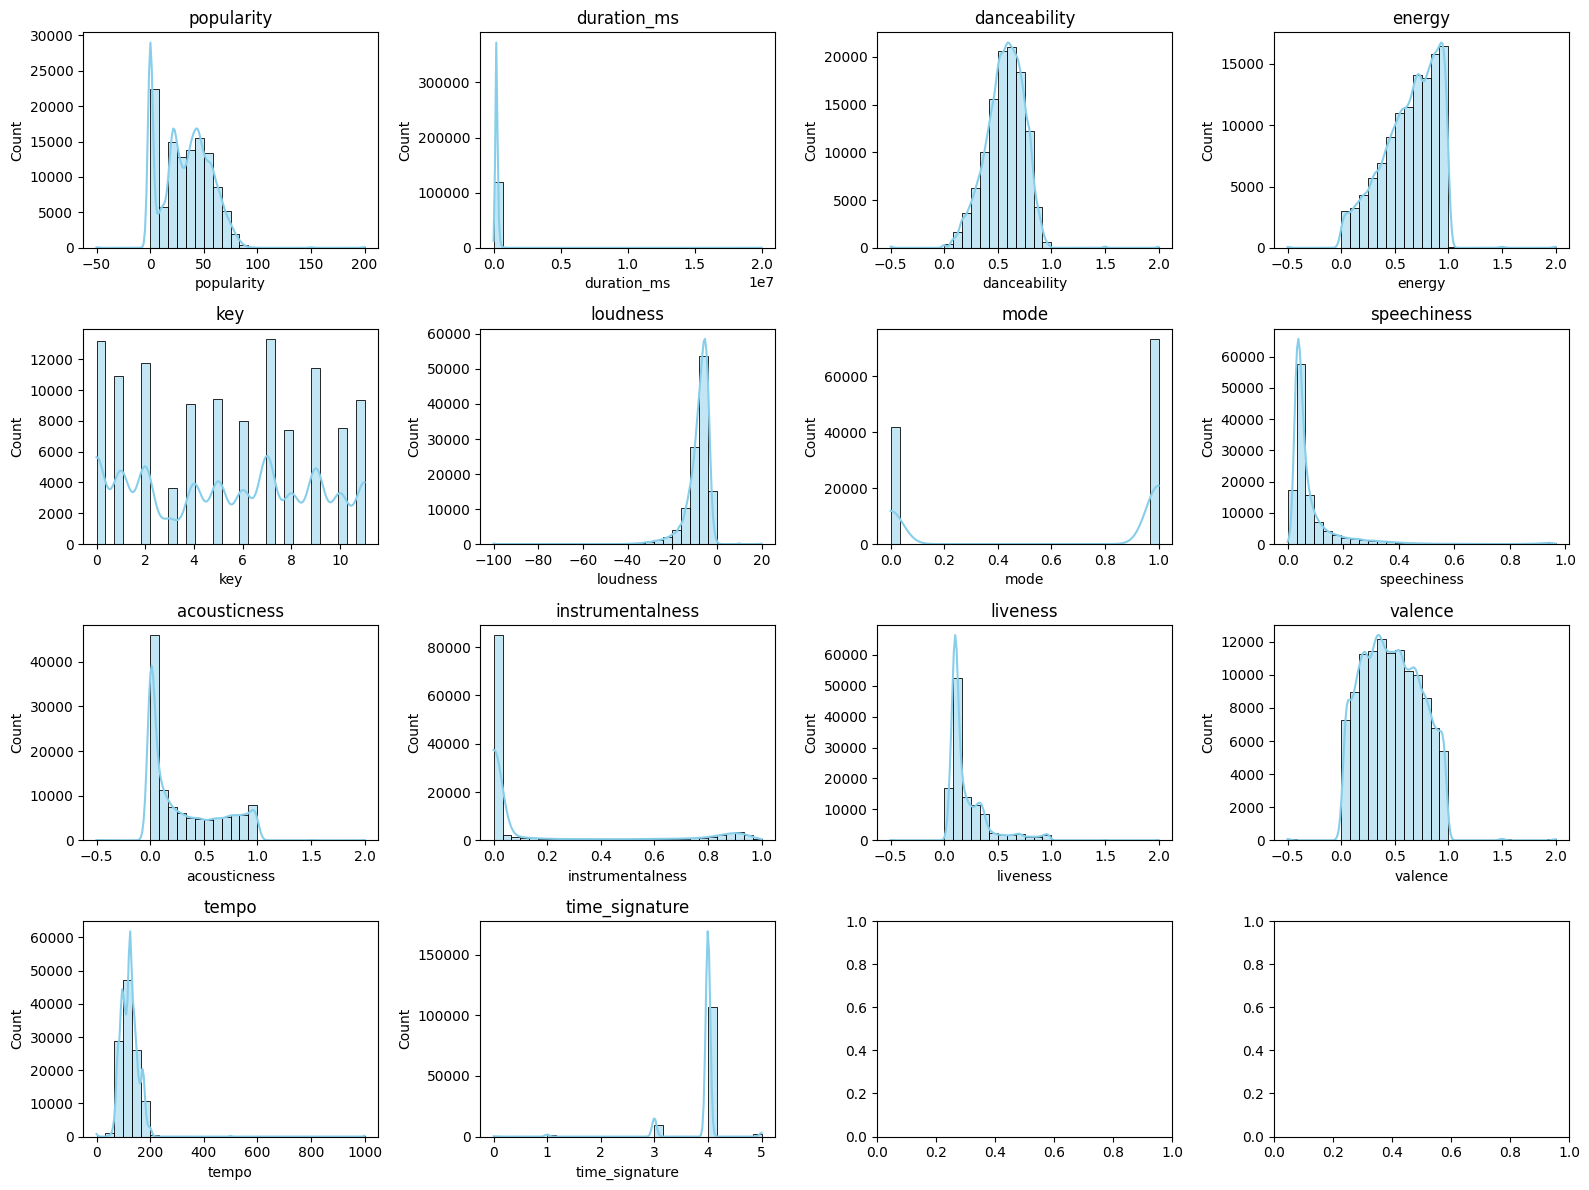

In [6]:
# постройте распределения числовых признаков
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(4, 4, figsize=(16, 12))
axes = axes.ravel()

for i, col in enumerate(numeric_columns[1:]):
    if i < len(axes):
        sns.histplot(data=data, x=col, bins=30, kde=True, ax=axes[i], color='skyblue')
        axes[i].set_title(f'{col}')

plt.tight_layout()
plt.show()

In [7]:
print(categorical_columns)

Index(['track_id', 'artists', 'album_name', 'track_name', 'track_genre'], dtype='object')


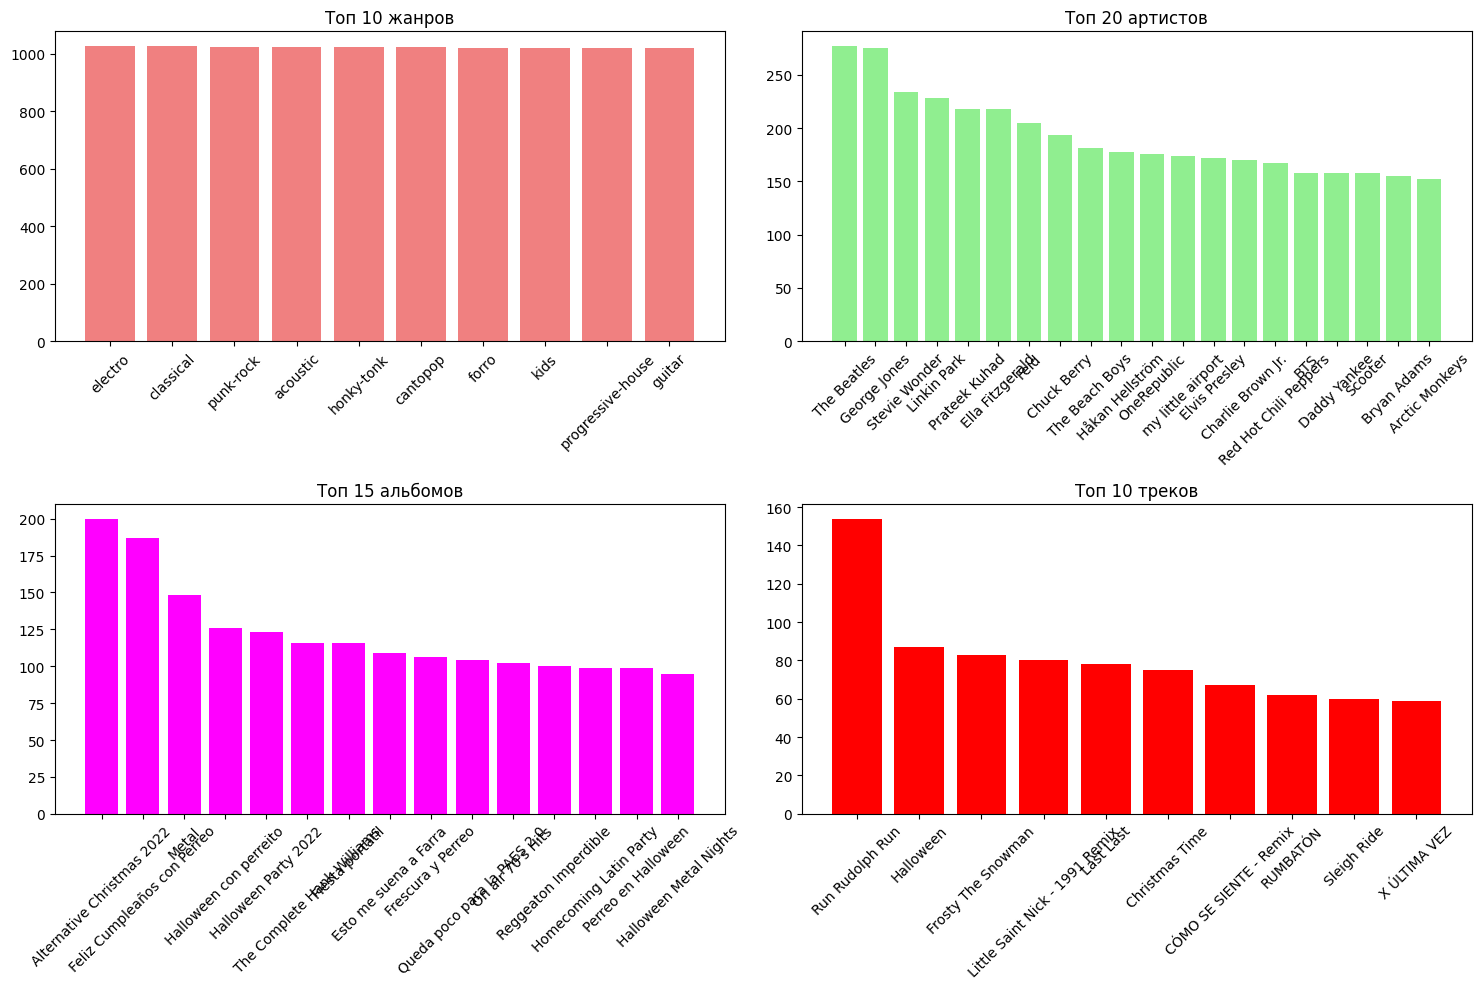

In [8]:
# постройте диаграммы частот категориальных признаков
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.ravel()

top_genres = data['track_genre'].value_counts().head(10)
axes[0].bar(range(len(top_genres)), top_genres.values, color='lightcoral')
axes[0].set_title('Топ 10 жанров')
axes[0].set_xticks(range(len(top_genres)))
axes[0].set_xticklabels(top_genres.index, rotation=45)

top_artists = data['artists'].value_counts().head(20)
axes[1].bar(range(len(top_artists)), top_artists.values, color='lightgreen')
axes[1].set_title('Топ 20 артистов')
axes[1].set_xticks(range(len(top_artists)))
axes[1].set_xticklabels(top_artists.index, rotation=45)

top_artists = data['album_name'].value_counts().head(15)
axes[2].bar(range(len(top_artists)), top_artists.values, color='magenta')
axes[2].set_title('Топ 15 альбомов')
axes[2].set_xticks(range(len(top_artists)))
axes[2].set_xticklabels(top_artists.index, rotation=45)

top_artists = data['track_name'].value_counts().head(10)
axes[3].bar(range(len(top_artists)), top_artists.values, color='red')
axes[3].set_title('Топ 10 треков')
axes[3].set_xticks(range(len(top_artists)))
axes[3].set_xticklabels(top_artists.index, rotation=45)
plt.tight_layout()
plt.show()

In [9]:
# выведите количество уникальных значений по каждому признаку
print("Количество уникальных значений по признакам:")
unique_counts = data.nunique().sort_values(ascending=False)
print(unique_counts)

Количество уникальных значений по признакам:
index               114000
track_id             89741
track_name           71540
duration_ms          50654
album_name           45566
tempo                44720
artists              30773
loudness             19269
instrumentalness      5338
acousticness          5048
energy                2067
valence               1787
liveness              1723
speechiness           1485
danceability          1170
track_genre            114
popularity             104
key                     12
time_signature           5
mode                     2
explicit                 2
dtype: int64


In [10]:
# подсчитайте долю пропусков по каждому признаку и отсортируйте признаки по убыванию доли
missing_percent = (data.isnull().sum() / len(data)) * 100
missing_percent = missing_percent[missing_percent > 0].sort_values(ascending=False)
print("Доля пропусков по признакам (%):")
print(missing_percent)

Доля пропусков по признакам (%):
key                 3.959900
instrumentalness    3.924812
track_name          3.922306
artists             3.894737
energy              3.893901
danceability        3.893901
track_genre         3.878864
acousticness        3.866332
liveness            3.865497
tempo               3.859649
loudness            3.852130
mode                3.810359
popularity          3.802840
speechiness         3.796157
album_name          3.777778
valence             3.763576
dtype: float64


## 3. Дубликаты и пропуски

In [11]:
# найдите полные дубликаты
full_duplicates = data.duplicated()
print(f"Количество полных дубликатов: {full_duplicates.sum()}")

# найдите частичные дубликаты
partial_duplicates = data.duplicated(subset=['track_id'])
print(f"Количество частичных дубликатов (по track_id): {partial_duplicates.sum()}")

Количество полных дубликатов: 1611
Количество частичных дубликатов (по track_id): 29959


In [12]:
# удалите дубликаты и зафиксируйте кол-во удаленных записей
initial_count = len(data)
data_no_duplicates = data.drop_duplicates()
final_count = len(data_no_duplicates)
removed_count = initial_count - final_count

print(f"Изначальное количество записей: {initial_count}")
print(f"Удалено дубликатов: {removed_count}")
print(f"Финальное количество записей: {final_count}")

Изначальное количество записей: 119700
Удалено дубликатов: 1611
Финальное количество записей: 118089


### можно ли было агрегировать дубликаты вместо удаления и почему?
Агрегирование дубликатов возможно в следующих случаях:
1. Если дубликаты отличаются только вспомогательными полями
2. Если можно усреднить числовые значения
3. Если можно объединить категориальные значения

Дубликаты могут быть валидными когда:
- Один и тот же трек записан в разных альбомах
- Разные версии одного трека (live, acoustic и т.д.)
- Ошибки в данных (один трек с разными ID)
- Агрегированные данные из разных источников

В данном случае лучше удалять точные дубликаты, а частичные анализировать дополнительно.

In [13]:
# выявите все признаки с пропущенными значениями
missing_data = data.isnull().sum()
missing_features = missing_data[missing_data > 0]
print("Признаки с пропущенными значениями:")
print(missing_features)

Признаки с пропущенными значениями:
artists             4662
album_name          4522
track_name          4695
popularity          4552
danceability        4661
energy              4661
key                 4740
loudness            4611
mode                4561
speechiness         4544
acousticness        4628
instrumentalness    4698
liveness            4627
valence             4505
tempo               4620
track_genre         4643
dtype: int64


In [14]:
# Выберите и примените наиболее подходящий метод устранения пропусков
# Для категориальных признаков - удаление строк с пропусками
# Выбрано удаление, так как это позволяет сохранить достоверность данных без искусственного заполнения

categorical_missing = ['artists', 'album_name', 'track_name', 'track_genre']

# Удаление строк с пропусками в категориальных столбцах
initial_count = len(data)
data = data.dropna(subset=categorical_missing)
final_count = len(data)

print(f"Удалено строк с пропусками: {initial_count - final_count}")
print(f"Осталось строк: {final_count}")

# Для числовых признаков - заполнение медианой
# Выбрана медиана, как самая устойчивая к выбросам, и так как она 
# характеризует "типичное" значение
numeric_missing = numeric_columns[numeric_columns.isin(missing_features.index)]
for col in numeric_missing:
    median_value = data[col].median()
    data[col] = data[col].fillna(median_value)
    print(f"Заполнен {col} медианой: {median_value}")

print("Все пропуски обработаны")

Удалено строк с пропусками: 17467
Осталось строк: 102233
Заполнен popularity медианой: 35.0
Заполнен danceability медианой: 0.581
Заполнен energy медианой: 0.684
Заполнен key медианой: 5.0
Заполнен loudness медианой: -6.999
Заполнен mode медианой: 1.0
Заполнен speechiness медианой: 0.0488
Заполнен acousticness медианой: 0.169
Заполнен instrumentalness медианой: 4.075e-05
Заполнен liveness медианой: 0.132
Заполнен valence медианой: 0.464
Заполнен tempo медианой: 122.026
Все пропуски обработаны


## 4. Работа с числовыми и категориальными признаками

In [15]:
# закодируйте все категориальные признаки наиболее подходящим методом
from sklearn.preprocessing import LabelEncoder

# Для номинальных категориальных признаков используем one-hot encoding
categorical_cols = ['artists', 'album_name', 'track_name', 'track_genre']

# Так как artists и track_name имеют много уникальных значений, используем Label Encoding
le_artists = LabelEncoder()
le_album = LabelEncoder()
le_track = LabelEncoder()

data['artists_encoded'] = le_artists.fit_transform(data['artists'])
data['album_name_encoded'] = le_album.fit_transform(data['album_name'])
data['track_name_encoded'] = le_track.fit_transform(data['track_name'])

# Для track_genre используем one-hot encoding, так как это ограниченное число категорий
genre_dummies = pd.get_dummies(data['track_genre'], prefix='genre')
data = pd.concat([data, genre_dummies], axis=1)

print("Категориальные признаки закодированы")
print("One-hot encoding применен для track_genre")
data[["artists_encoded",'album_name_encoded','track_name_encoded']].head()

Категориальные признаки закодированы
One-hot encoding применен для track_genre


,artists_encoded,album_name_encoded,track_name_encoded
0,9572,7416,10458
1,3030,13505,20051
2,11440,35715,54171
3,13708,7856,8507
4,4858,15421,22888


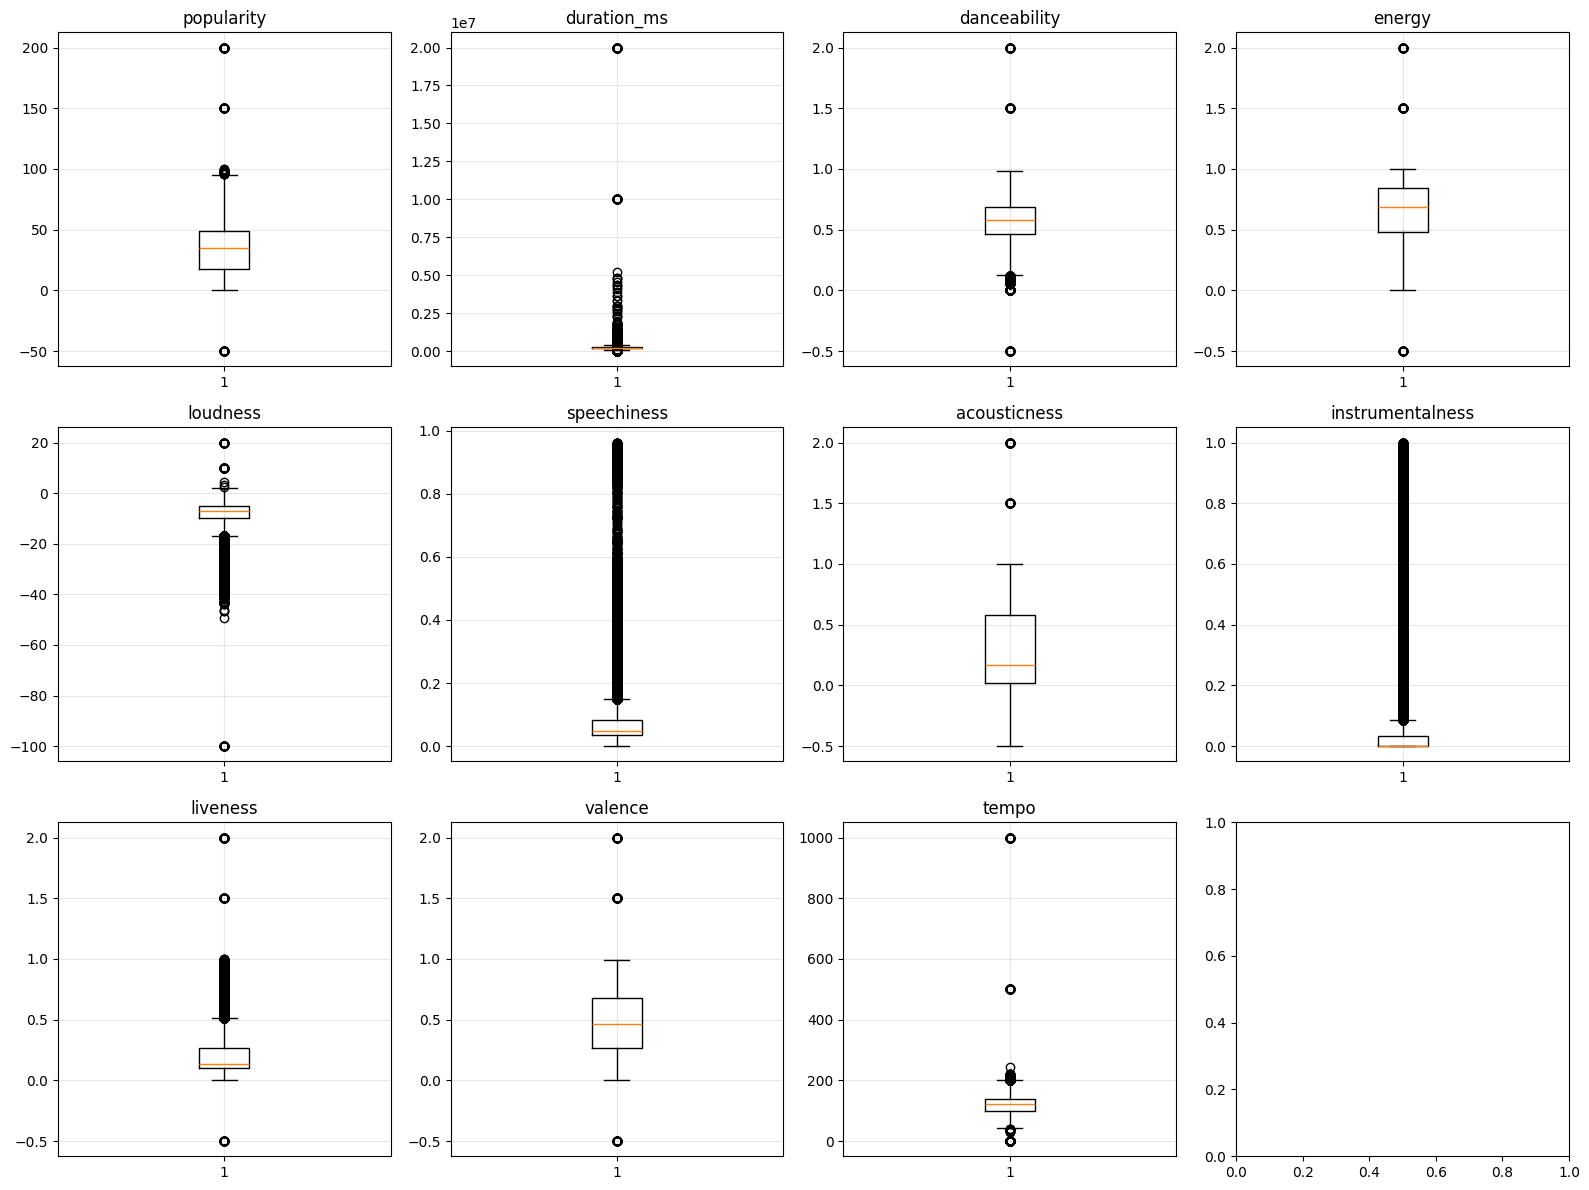

In [16]:
# найдите и опишите выбросы (визуализация + по правилу 3х сигм, IQR)
import matplotlib.pyplot as plt

# Визуализация выбросов через boxplot
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.ravel()

numeric_features = ['popularity', 'duration_ms', 'danceability', 'energy', 'loudness', 
                   'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']

for i, col in enumerate(numeric_features):
    if i < len(axes):
        axes[i].boxplot(data[col])
        axes[i].set_title(f'{col}')
        axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [17]:
# Поиск выбросов по правилу 3 сигм
outliers_3sigma = {}
for col in numeric_features:
    mean = data[col].mean()
    std = data[col].std()
    lower_bound = mean - 3 * std
    upper_bound = mean + 3 * std
    outliers = data[(data[col] < lower_bound) | (data[col] > upper_bound)]
    outliers_3sigma[col] = len(outliers)
    print(f"{col}: выбросов по 3σ = {len(outliers)}")

# Поиск выбросов по IQR
outliers_iqr = {}
for col in numeric_features:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[col] < lower_bound) | (data[col] > upper_bound)]
    outliers_iqr[col] = len(outliers)
    print(f"{col}: выбросов по IQR = {len(outliers)}")

popularity: выбросов по 3σ = 147
duration_ms: выбросов по 3σ = 144
danceability: выбросов по 3σ = 280
energy: выбросов по 3σ = 144
loudness: выбросов по 3σ = 2014
speechiness: выбросов по 3σ = 1888
acousticness: выбросов по 3σ = 99
instrumentalness: выбросов по 3σ = 0
liveness: выбросов по 3σ = 3121
valence: выбросов по 3σ = 145
tempo: выбросов по 3σ = 289
popularity: выбросов по IQR = 165
duration_ms: выбросов по IQR = 5153
danceability: выбросов по IQR = 937
energy: выбросов по IQR = 144
loudness: выбросов по IQR = 5996
speechiness: выбросов по IQR = 12218
acousticness: выбросов по IQR = 99
instrumentalness: выбросов по IQR = 22919
liveness: выбросов по IQR = 8001
valence: выбросов по IQR = 145
tempo: выбросов по IQR = 820


Выбор метода устранения выбросов:

Для данного датасета cтоит:
1. Не удалять выбросы полностью, а использовать ограничение
2. Для признаков типа loudness, tempo - ограничение на 1% и 99% перцентили
3. Для музыкальных характеристик (danceability, energy и т.д.) - оставить как есть, 
   так как экстремальные значения могут быть валидными (очень энергичная или тихая музыка)

Обоснование: выбросы в музыкальных данных часто представляют собой реальные особенности 
(очень популярные треки, очень громкие записи и т.д.) и могут быть важны для анализа.

popularity: асимметрия = 0.290
duration_ms: асимметрия = 31.551
danceability: асимметрия = -0.209
energy: асимметрия = -0.546
loudness: асимметрия = -3.525
speechiness: асимметрия = 4.755
acousticness: асимметрия = 0.836
instrumentalness: асимметрия = 1.798
liveness: асимметрия = 2.500
valence: асимметрия = 0.201
tempo: асимметрия = 8.228


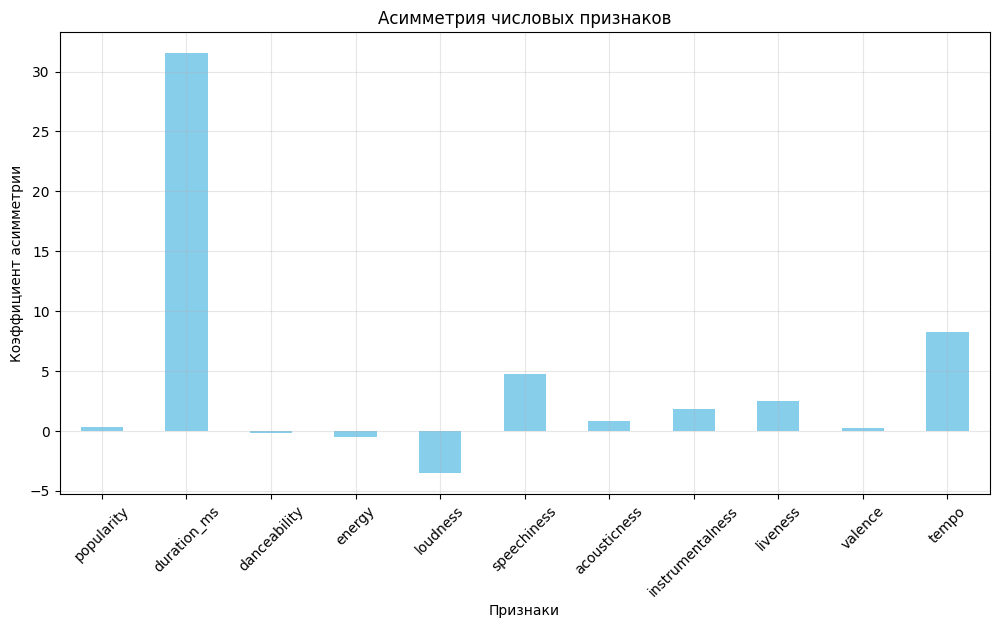

In [18]:
# вычислите асимметрию в распределениях числовых признаков
from scipy.stats import skew

skewness_results = {}
for col in numeric_features:
    skewness = skew(data[col])
    skewness_results[col] = skewness
    print(f"{col}: асимметрия = {skewness:.3f}")

# Визуализация асимметрии
skewness_series = pd.Series(skewness_results)
plt.figure(figsize=(12, 6))
skewness_series.plot(kind='bar', color='skyblue')
plt.title('Асимметрия числовых признаков')
plt.ylabel('Коэффициент асимметрии')
plt.xlabel('Признаки')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.show()

In [19]:
# по вычисленной асимметрии и по ранее построенным распределениям числовых признаков 
# выберите наиболее подходящее масштабирование

Выбор масштабирования:

На основе асимметрии:
- Сильно асимметричные признаки (|skew| > 1)
  → Используем RobustScaler

- Умеренно асимметричные признаки (0.5 < |skew| < 1)
  → Применим MinMax

- Близкие к нормальным (|skew| < 0.5): danceability, energy, valence, tempo
  → Возьмем StandardScaler

Обоснование выбора StandardScaler + RobustScaler + MinMaxScaler:
- StandardScaler для нормально распределенных признаков
- RobustScaler для признаков с выбросами
- Это обеспечит лучшую устойчивость к выбросам и сохранит структуру данных

In [20]:
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler
from scipy import stats

data_processed = data.copy()

# Метод 1: Winsorization для умеренных выбросов
def winsorize_data(data, columns, limits=(5, 95)):
    """Winsorize данные - заменяет экстремальные значения на перцентили"""
    data_winsorized = data.copy()
    for col in columns:
        if col in data_winsorized.columns:  # Проверка существования колонки
            lower_limit, upper_limit = np.percentile(data_winsorized[col].dropna(), [limits[0], limits[1]])
            data_winsorized[col] = np.clip(data_winsorized[col], lower_limit, upper_limit)
    return data_winsorized

# Определим признаки с умеренными выбросами (0.5 < |skew| < 1)
moderate_skew_features = [col for col, skew_val in skewness_results.items() 
                         if 0.5 < abs(skew_val) <= 1 and col in data.columns]

print(f"Признаки с умеренной асимметрией для winsorization: {moderate_skew_features}")

# Применяем winsorization
if moderate_skew_features:  # Проверка, что есть признаки для обработки
    data_processed = winsorize_data(data_processed, moderate_skew_features, limits=(1, 99))
    print("Winsorization применена успешно")
else:
    print("Нет признаков с умеренной асимметрией для winsorization")

Признаки с умеренной асимметрией для winsorization: ['energy', 'acousticness']
Winsorization применена успешно


In [21]:
# Метод 2: IQR-метод для сильных выбросов
def remove_outliers_iqr(data, columns, factor=1.5):
    """Удаление выбросов по методу IQR"""
    data_clean = data.copy()
    outliers_info = {}
    
    for col in columns:
        Q1 = data_clean[col].quantile(0.25)
        Q3 = data_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - factor * IQR
        upper_bound = Q3 + factor * IQR
        
        # Подсчитываем выбросы
        outliers_count = len(data_clean[(data_clean[col] < lower_bound) | (data_clean[col] > upper_bound)])
        outliers_info[col] = outliers_count
        
        # Winsorize вместо удаления (сохраняем структуру данных)
        data_clean[col] = np.clip(data_clean[col], lower_bound, upper_bound)
    
    return data_clean, outliers_info

# Определим признаки с сильной асимметрией (|skew| > 1)
high_skew_features = [col for col, skew_val in skewness_results.items() 
                     if abs(skew_val) > 1]

print(f"Признаки с сильной асимметрией для IQR-обработки: {high_skew_features}")

# Применяем IQR-метод с winsorization
data_processed, outliers_removed = remove_outliers_iqr(data_processed, high_skew_features, factor=1.5)

print("Количество выбросов по IQR-методу:")
for feature, count in outliers_removed.items():
    print(f"  {feature}: {count}")

Признаки с сильной асимметрией для IQR-обработки: ['duration_ms', 'loudness', 'speechiness', 'instrumentalness', 'liveness', 'tempo']
Количество выбросов по IQR-методу:
  duration_ms: 5153
  loudness: 5996
  speechiness: 12218
  instrumentalness: 22919
  liveness: 8001
  tempo: 820


In [22]:
# Метод 3: Z-score для нормальных распределений
def remove_outliers_zscore(data, columns, threshold=3):
    """Удаление выбросов по Z-score"""
    data_clean = data.copy()
    outliers_info = {}
    
    for col in columns:
        z_scores = np.abs(stats.zscore(data_clean[col]))
        outliers_mask = z_scores > threshold
        outliers_count = np.sum(outliers_mask)
        outliers_info[col] = outliers_count
        
        # Winsorize вместо удаления
        if outliers_count > 0:
            # Находим границы для winsorization
            valid_data = data_clean[col][~outliers_mask]
            lower_bound = valid_data.min()
            upper_bound = valid_data.max()
            data_clean[col] = np.clip(data_clean[col], lower_bound, upper_bound)
    
    return data_clean, outliers_info

# Определим признаки, близкие к нормальным (|skew| < 0.5)
normal_features = [col for col, skew_val in skewness_results.items() 
                  if abs(skew_val) <= 0.5]

print(f"Признаки с нормальным распределением: {normal_features}")

# Применяем Z-score метод с winsorization
data_processed, zscore_outliers = remove_outliers_zscore(data_processed, normal_features, threshold=3)

print("Количество выбросов по Z-score методу:")
for feature, count in zscore_outliers.items():
    print(f"  {feature}: {count}")

Признаки с нормальным распределением: ['popularity', 'danceability', 'valence']
Количество выбросов по Z-score методу:
  popularity: 147
  danceability: 280
  valence: 145


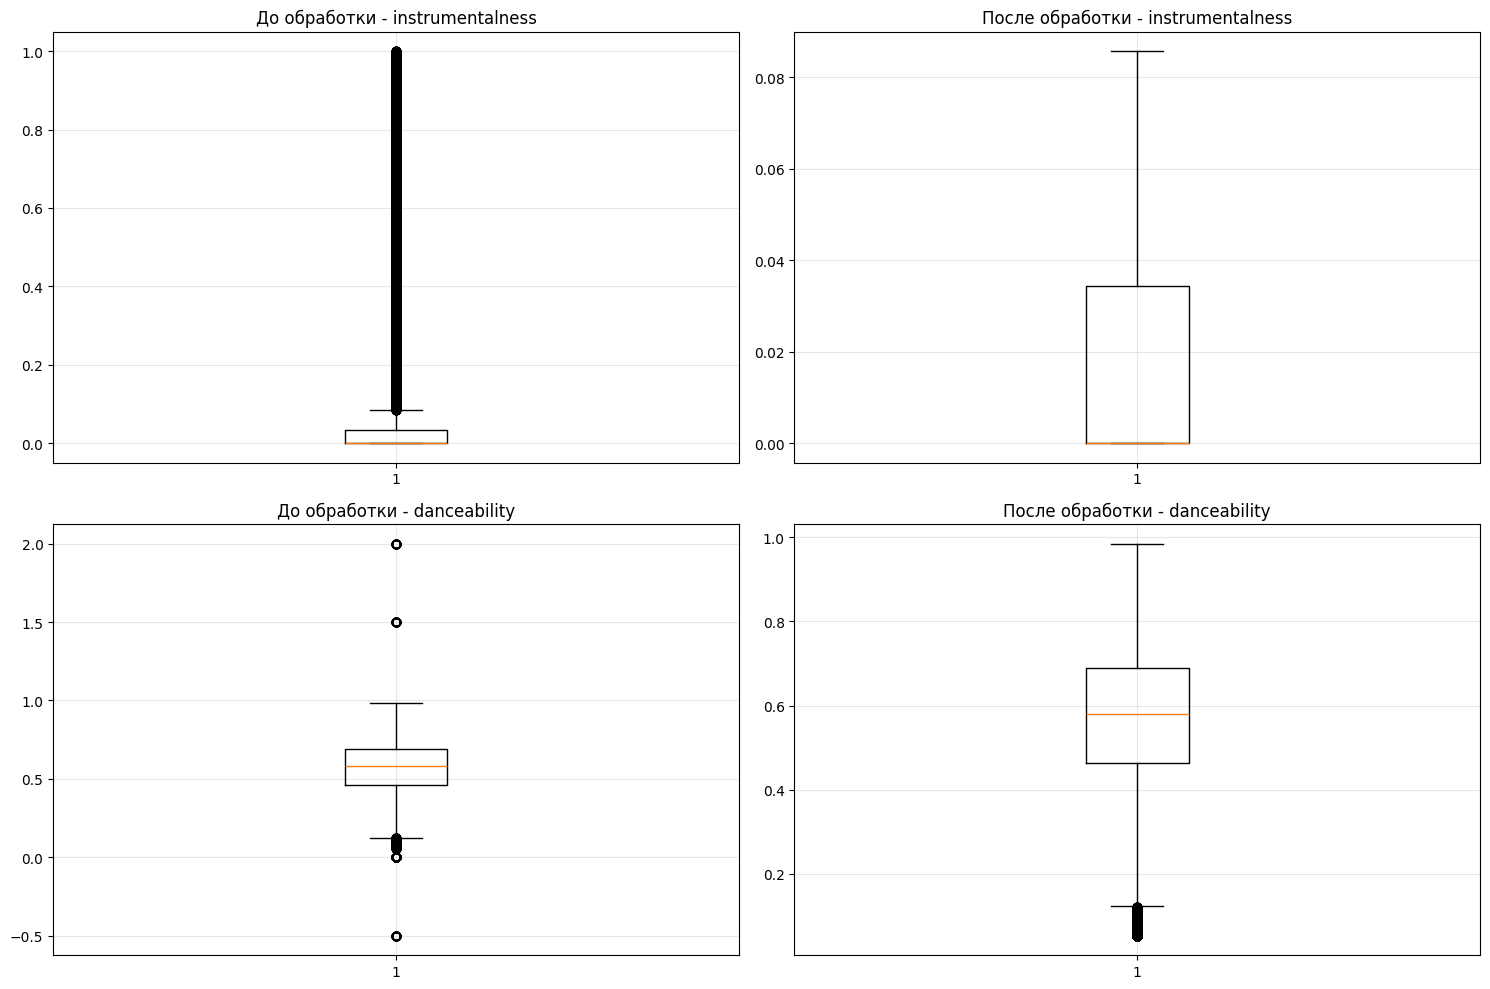

In [23]:
# Визуализация до и после обработки выбросов
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Пример для сильно асимметричного признака (instrumentalness)
axes[0, 0].boxplot(data['instrumentalness'])
axes[0, 0].set_title('До обработки - instrumentalness')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].boxplot(data_processed['instrumentalness'])
axes[0, 1].set_title('После обработки - instrumentalness')
axes[0, 1].grid(True, alpha=0.3)

# Пример для нормального признака (danceability)
axes[1, 0].boxplot(data['danceability'])
axes[1, 0].set_title('До обработки - danceability')
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].boxplot(data_processed['danceability'])
axes[1, 1].set_title('После обработки - danceability')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [24]:
# Сравнение статистик до и после обработки выбросов
print("Сравнение статистик до и после обработки выбросов:")
print("\n=== ДО ===")
print(data[numeric_features].describe().loc[['mean', 'std', 'min', 'max']])

print("\n=== ПОСЛЕ ===")
print(data_processed[numeric_features].describe().loc[['mean', 'std', 'min', 'max']])

Сравнение статистик до и после обработки выбросов:

=== ДО ===
      popularity   duration_ms  danceability    energy    loudness  \
mean   33.415717  2.452187e+05      0.568422  0.643549   -8.219620   
std    22.435180  5.524487e+05      0.175296  0.250131    5.278136   
min   -50.000000  1.000000e+03     -0.500000 -0.500000 -100.000000   
max   200.000000  2.000000e+07      2.000000  2.000000   20.000000   

      speechiness  acousticness  instrumentalness  liveness   valence  \
mean     0.082914      0.310131          0.149936  0.211363  0.475196   
std      0.103111      0.330558          0.304968  0.194449  0.257862   
min      0.000000     -0.500000          0.000000 -0.500000 -0.500000   
max      0.963000      2.000000          1.000000  2.000000  2.000000   

            tempo  
mean   122.796959  
std     37.332147  
min      0.000000  
max   1000.000000  

=== ПОСЛЕ ===
      popularity    duration_ms  danceability    energy   loudness  \
mean   33.359473  222551.015367    

In [25]:
# Выбор масштабирования по описанному принципу
# Создаем отдельные группы признаков для разных типов масштабирования
# Сильно асимметричные признаки (|skew| > 1) → RobustScaler
high_skew_features = [col for col, skew_val in skewness_results.items() 
                     if abs(skew_val) > 1]

# Умеренно асимметричные признаки (0.5 < |skew| < 1) → MinMaxScaler
moderate_skew_features = [col for col, skew_val in skewness_results.items() 
                         if 0.5 < abs(skew_val) <= 1]

# Близкие к нормальным (|skew| < 0.5) → StandardScaler
normal_features = [col for col, skew_val in skewness_results.items() 
                  if abs(skew_val) <= 0.5]

print("Группировка признаков для масштабирования:")
print(f"RobustScaler (сильная асимметрия): {high_skew_features}")
print(f"MinMaxScaler (умеренная асимметрия): {moderate_skew_features}")
print(f"StandardScaler (нормальное распределение): {normal_features}")

Группировка признаков для масштабирования:
RobustScaler (сильная асимметрия): ['duration_ms', 'loudness', 'speechiness', 'instrumentalness', 'liveness', 'tempo']
MinMaxScaler (умеренная асимметрия): ['energy', 'acousticness']
StandardScaler (нормальное распределение): ['popularity', 'danceability', 'valence']


In [26]:
# Применяем разные методы масштабирования к соответствующим группам признаков
from sklearn.compose import ColumnTransformer

# Создаем ColumnTransformer с разными скалерами для разных групп
preprocessor = ColumnTransformer(
    transformers=[
        ('robust', RobustScaler(), high_skew_features if high_skew_features else ['popularity']),  # защита от пустого списка
        ('minmax', MinMaxScaler(), moderate_skew_features if moderate_skew_features else ['duration_ms']),
        ('standard', StandardScaler(), normal_features if normal_features else ['danceability'])
    ],
    remainder='passthrough'  # Остальные признаки оставляем без изменений
)

# Применяем масштабирование
try:
    scaled_data = preprocessor.fit_transform(data_processed[numeric_features])
    # Создаем DataFrame с масштабированными данными
    scaled_df = pd.DataFrame(scaled_data, columns=numeric_features)
    print("Масштабирование выполнено успешно")
    print("Форма масштабированных данных:", scaled_df.shape)
except Exception as e:
    print(f"Ошибка при масштабировании: {e}")
    # Альтернативный подход - масштабируем все признаки одним методом
    scaler = RobustScaler()
    scaled_data = scaler.fit_transform(data_processed[numeric_features])
    scaled_df = pd.DataFrame(scaled_data, columns=numeric_features)
    print("Использован альтернативный метод масштабирования (RobustScaler для всех)")

Масштабирование выполнено успешно
Форма масштабированных данных: (102233, 11)


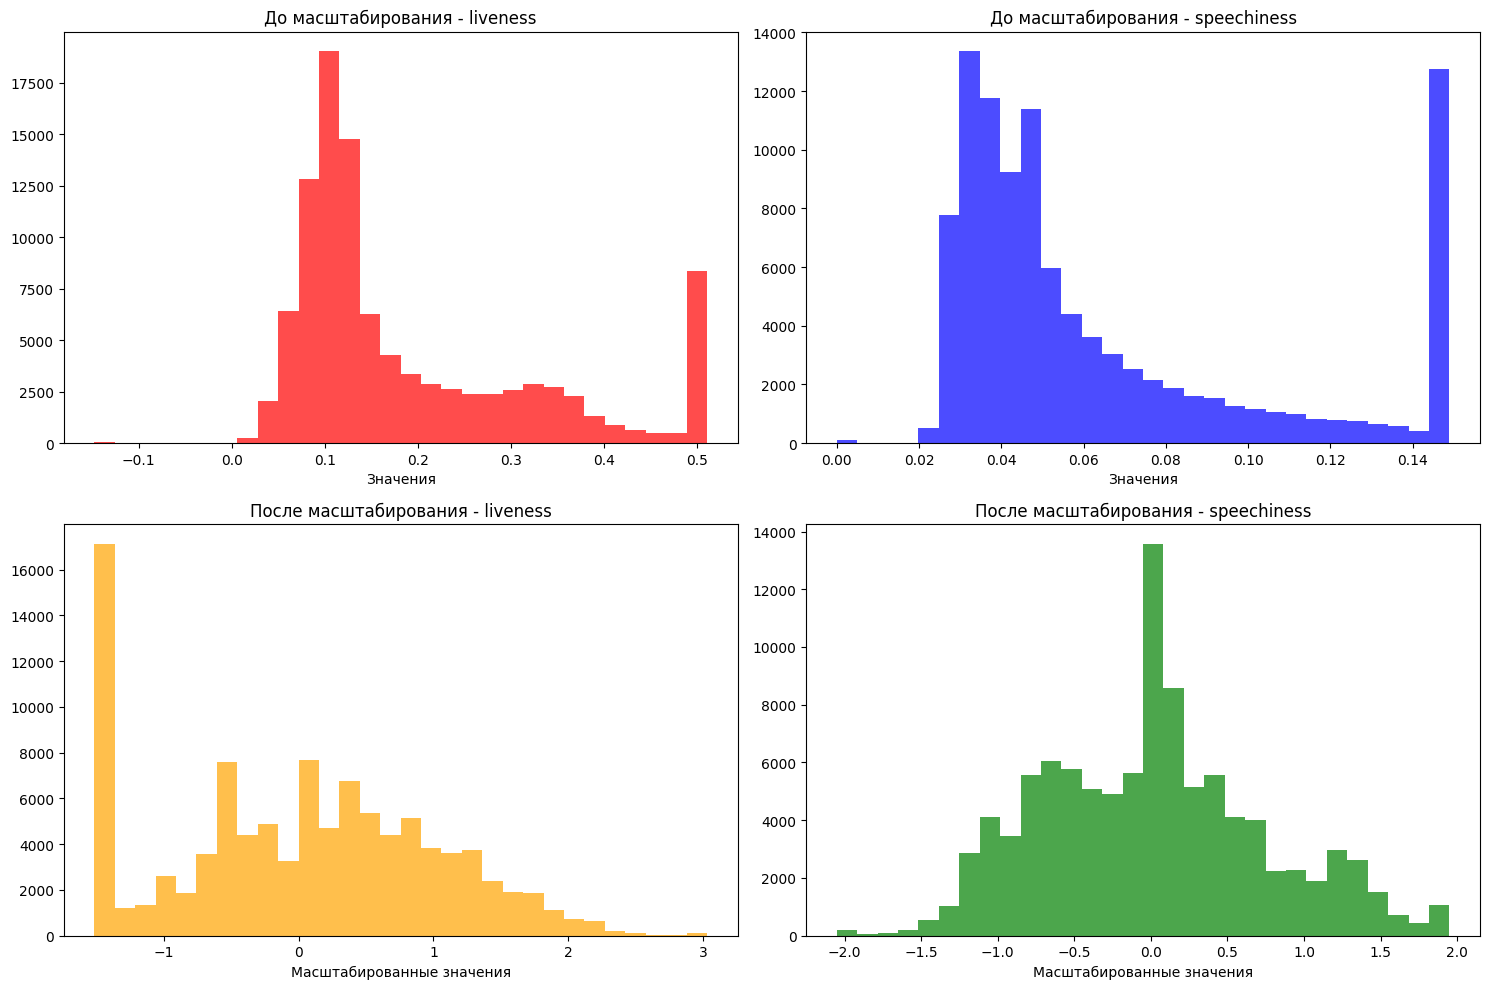

In [45]:
# Визуализация результатов масштабирования
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# До масштабирования
axes[0, 0].hist(data_processed['liveness'], bins=30, alpha=0.7, color='red')
axes[0, 0].set_title('До масштабирования - liveness')
axes[0, 0].set_xlabel('Значения')

axes[0, 1].hist(data_processed['speechiness'], bins=30, alpha=0.7, color='blue')
axes[0, 1].set_title('До масштабирования - speechiness')
axes[0, 1].set_xlabel('Значения')

# После масштабирования
axes[1, 0].hist(scaled_df['liveness'], bins=30, alpha=0.7, color='orange')
axes[1, 0].set_title('После масштабирования - liveness')
axes[1, 0].set_xlabel('Масштабированные значения')

axes[1, 1].hist(scaled_df['speechiness'], bins=30, alpha=0.7, color='green')
axes[1, 1].set_title('После масштабирования - speechiness')
axes[1, 1].set_xlabel('Масштабированные значения')

plt.tight_layout()
plt.show()

In [28]:
# Сравнение статистик до и после обработки выбросов
print("Сравнение статистик до и после обработки выбросов:")
print("\n=== ДО ===")
before_stats = data[numeric_features].describe().loc[['mean', 'std', 'min', 'max']]
print(before_stats)

print("\n=== ПОСЛЕ ===")
after_stats = data_processed[numeric_features].describe().loc[['mean', 'std', 'min', 'max']]
print(after_stats)

# Подсчет изменения
print("\n=== ИЗМЕНЕНИЯ ===")
for col in numeric_features:
    if col in before_stats.columns and col in after_stats.columns:
        mean_change = abs(after_stats[col]['mean'] - before_stats[col]['mean'])
        std_change = abs(after_stats[col]['std'] - before_stats[col]['std'])
        print(f"{col}: изменение среднего = {mean_change:.6f}, изменение std = {std_change:.6f}")

Сравнение статистик до и после обработки выбросов:

=== ДО ===
      popularity   duration_ms  danceability    energy    loudness  \
mean   33.415717  2.452187e+05      0.568422  0.643549   -8.219620   
std    22.435180  5.524487e+05      0.175296  0.250131    5.278136   
min   -50.000000  1.000000e+03     -0.500000 -0.500000 -100.000000   
max   200.000000  2.000000e+07      2.000000  2.000000   20.000000   

      speechiness  acousticness  instrumentalness  liveness   valence  \
mean     0.082914      0.310131          0.149936  0.211363  0.475196   
std      0.103111      0.330558          0.304968  0.194449  0.257862   
min      0.000000     -0.500000          0.000000 -0.500000 -0.500000   
max      0.963000      2.000000          1.000000  2.000000  2.000000   

            tempo  
mean   122.796959  
std     37.332147  
min      0.000000  
max   1000.000000  

=== ПОСЛЕ ===
      popularity    duration_ms  danceability    energy   loudness  \
mean   33.359473  222551.015367    

duration_ms мне вообще не нравится

In [29]:
print("Исходные данные по duration_ms:")
print(f"Количество нулевых значений: {len(data[data['duration_ms'] == 0])}")
print(f"Количество значений < 10000: {len(data[data['duration_ms'] < 10000])}")
print(f"Количество значений > 1000000: {len(data[data['duration_ms'] > 1000000])}")
print(f"Медиана: {data['duration_ms'].median()}")
print(f"99-й перцентиль: {data['duration_ms'].quantile(0.99)}")
print(f"99.9-й перцентиль: {data['duration_ms'].quantile(0.999)}")

Исходные данные по duration_ms:
Количество нулевых значений: 0
Количество значений < 10000: 69
Количество значений > 1000000: 215
Медиана: 212973.0
99-й перцентиль: 545126.4799999987
99.9-й перцентиль: 10000000.0


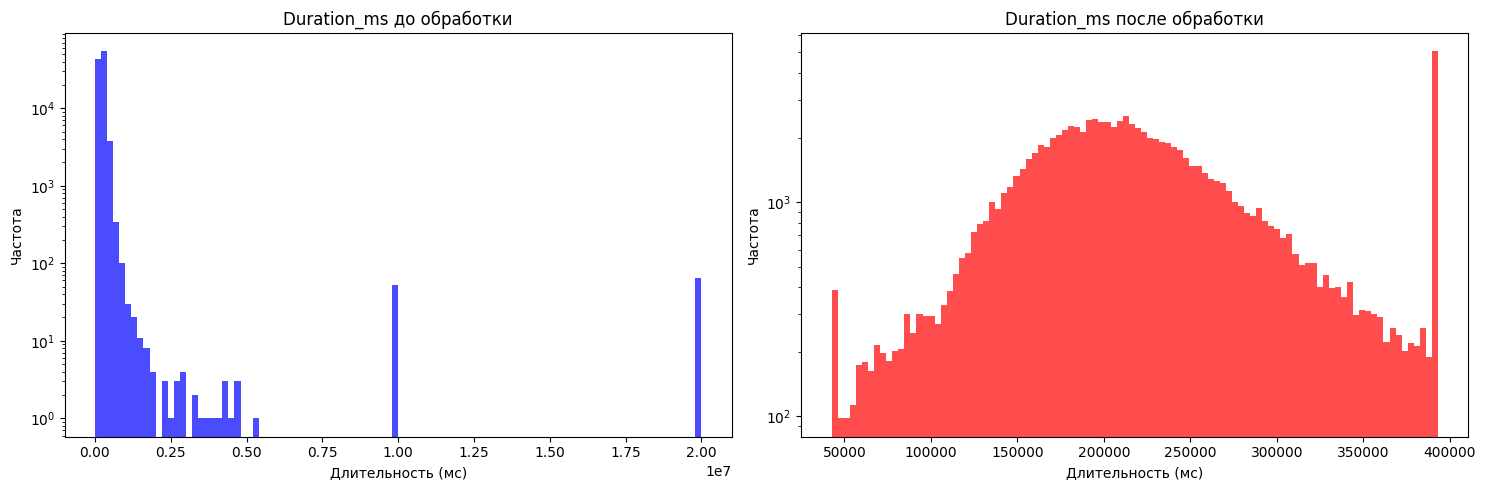

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# До обработки
axes[0].hist(data['duration_ms'].dropna(), bins=100, alpha=0.7, color='blue')
axes[0].set_title('Duration_ms до обработки')
axes[0].set_xlabel('Длительность (мс)')
axes[0].set_ylabel('Частота')
axes[0].set_yscale('log')

# После обработки
axes[1].hist(data_processed['duration_ms'].dropna(), bins=100, alpha=0.7, color='red')
axes[1].set_title('Duration_ms после обработки')
axes[1].set_xlabel('Длительность (мс)')
axes[1].set_ylabel('Частота')
axes[1].set_yscale('log')

plt.tight_layout()
plt.show()

После обработки явно лучше, может в датасет попали какие-нибудь подкасты или очень долгие треки

## 5. Анализ связи признаков с целевой переменной

In [31]:
# Определим целевую переменную (например, popularity)
target_variable = 'popularity'

# проверьте связь числовых переменных с целевой переменной
correlations = {}
for col in numeric_features:
    if col != target_variable:
        corr = data[col].corr(data[target_variable])
        correlations[col] = corr

# Сортировка по абсолютному значению корреляции
sorted_correlations = dict(sorted(correlations.items(), key=lambda x: abs(x[1]), reverse=True))

print("Корреляция числовых признаков с popularity:")
for feature, corr in sorted_correlations.items():
    print(f"{feature}: {corr:.3f}")

Корреляция числовых признаков с popularity:
instrumentalness: -0.089
loudness: 0.045
speechiness: -0.041
valence: -0.038
danceability: 0.032
acousticness: -0.023
tempo: 0.011
duration_ms: -0.005
liveness: -0.004
energy: 0.001


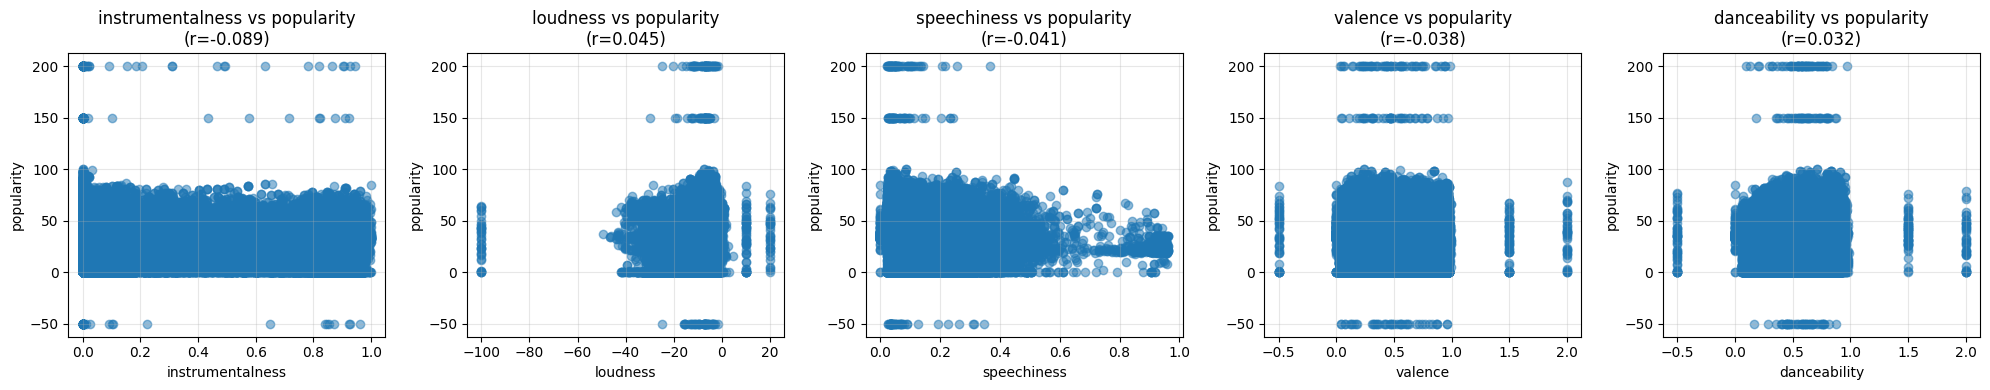

In [32]:
# Построим scatterplot для топ-5 коррелирующих признаков
top_corr_features = list(sorted_correlations.keys())[:5]

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for i, feature in enumerate(top_corr_features):
    axes[i].scatter(data[feature], data[target_variable], alpha=0.5)
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel(target_variable)
    axes[i].set_title(f'{feature} vs {target_variable}\n(r={sorted_correlations[feature]:.3f})')
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [33]:
# проверьте связь категориальных переменных с целевой переменной (ANOVA)
from scipy.stats import f_oneway

# Для демонстрации используем закодированные категориальные признаки
categorical_encoded = ['artists_encoded', 'album_name_encoded', 'explicit', 'mode']

print("ANOVA анализ для категориальных признаков:")
for cat_col in categorical_encoded:
    if cat_col in data.columns:
        # Группируем данные по категориям
        groups = [group[target_variable].values for name, group in data.groupby(cat_col)]
        if len(groups) > 1:
            try:
                f_stat, p_value = f_oneway(*groups)
                print(f"{cat_col}: F-stat={f_stat:.3f}, p-value={p_value:.6f}")
            except:
                print(f"{cat_col}: Не удалось провести ANOVA")

ANOVA анализ для категориальных признаков:
artists_encoded: F-stat=5.628, p-value=0.000000
album_name_encoded: F-stat=12.764, p-value=0.000000
explicit: F-stat=169.479, p-value=0.000000
mode: F-stat=13.020, p-value=0.000308


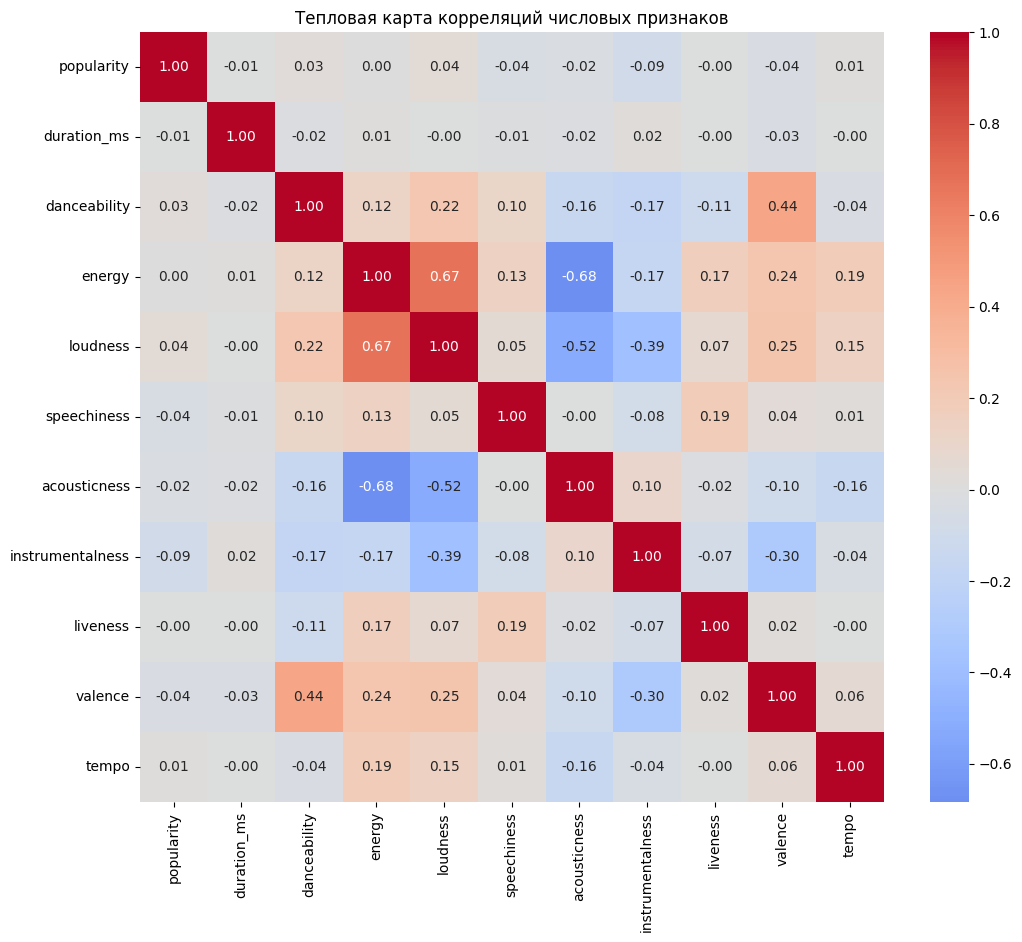

In [34]:
# постройте тепловую карту корреляций
plt.figure(figsize=(12, 10))
correlation_matrix = data[numeric_features].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Тепловая карта корреляций числовых признаков')
plt.show()

Самая значимая переменная по отношению к целевой - Instrumentallness
Но, как и все остальные, корреляция очень слабая.
Видно что energy, acousticness и loudness сильно коррелируют между друг другом
Возможно кем-то можно пренебречь


## 6. Работа с дисбалансом классов

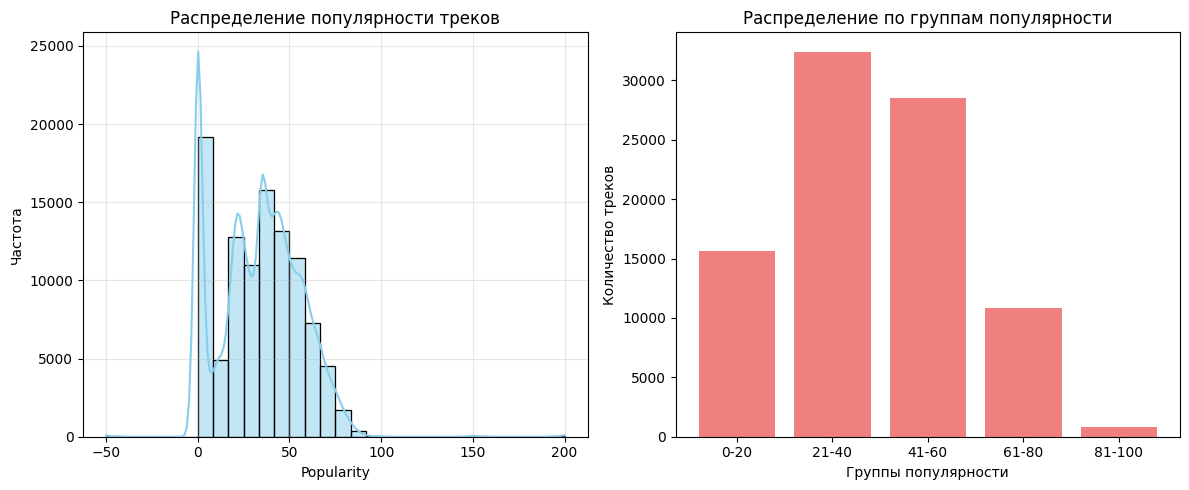

In [35]:
# визуально проверьте распределение целевого признака
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(data[target_variable], bins=30, color='skyblue', edgecolor='black', kde = True)
plt.xlabel('Popularity')
plt.ylabel('Частота')
plt.title('Распределение популярности треков')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
# Создадим категориальные группы популярности для лучшей визуализации
popularity_groups = pd.cut(data[target_variable], bins=[0, 20, 40, 60, 80, 100], 
                          labels=['0-20', '21-40', '41-60', '61-80', '81-100'])
popularity_counts = popularity_groups.value_counts().sort_index()
plt.bar(range(len(popularity_counts)), popularity_counts.values, color='lightcoral')
plt.xlabel('Группы популярности')
plt.ylabel('Количество треков')
plt.title('Распределение по группам популярности')
plt.xticks(range(len(popularity_counts)), popularity_counts.index)

plt.tight_layout()
plt.show()

- Данные представляют собой непрерывную переменную (популярность)
- Классы сильно дисбалансированы
- Лучше использовать искусственное увеличение данных

Можно так же увеличить веса наиболее популярных треков

In [36]:
# Проверим, сколько у нас записей с высокой популярностью
high_popularity = data[data['popularity'] > 80]
low_popularity = data[data['popularity'] <= 80]


In [37]:
# Создадим балансировку
from sklearn.utils import resample

# Цель: сделать соотношение примерно 1:2 (высокая популярность : низкая/средняя)
# Сейчас у нас 1051 высокопопулярных и 118649 остальных
# Хотим чтобы высокопопулярных было примерно половина от остальных: ~59000

target_high_pop_count = int(len(low_popularity) * 0.5)  # 50% от низкопопулярных
current_high_pop_count = len(high_popularity)
need_to_generate = target_high_pop_count - current_high_pop_count

print(f"ТЕКУЩАЯ СИТУАЦИЯ:")
print(f"Высокопопулярные: {current_high_pop_count}")
print(f"Низкопопулярные: {len(low_popularity)}")
print(f"Соотношение: 1 к {len(low_popularity)/current_high_pop_count:.1f}")

print(f"\nЦЕЛЕВАЯ БАЛАНСИРОВКА:")
print(f"Желаемое количество высокопопулярных: {target_high_pop_count}")
print(f"Нужно сгенерировать: {need_to_generate}")

ТЕКУЩАЯ СИТУАЦИЯ:
Высокопопулярные: 908
Низкопопулярные: 101325
Соотношение: 1 к 111.6

ЦЕЛЕВАЯ БАЛАНСИРОВКА:
Желаемое количество высокопопулярных: 50662
Нужно сгенерировать: 49754


In [38]:
# Генерируем синтетические данные для балансировки
synthetic_samples = resample(high_popularity, 
                            replace=True, 
                            n_samples=need_to_generate,
                            random_state=42)

# Добавим значительный шум (15-25%) для разнообразия
synthetic_samples_noisy = synthetic_samples.copy()
numeric_cols_for_noise = ['danceability', 'energy', 'loudness', 'speechiness', 
                         'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']

for col in numeric_cols_for_noise:
    if col in synthetic_samples_noisy.columns:
        # Значительный шум 15-25%
        noise = np.random.normal(0, np.random.uniform(0.15, 0.25), len(synthetic_samples_noisy))
        synthetic_samples_noisy[col] = synthetic_samples_noisy[col] + noise
        
        # Ограничиваем значения в допустимом диапазоне
        if col in ['danceability', 'energy', 'speechiness', 'acousticness', 'liveness', 'valence']:
            synthetic_samples_noisy[col] = np.clip(synthetic_samples_noisy[col], 0, 1)
        elif col == 'loudness':
            synthetic_samples_noisy[col] = np.clip(synthetic_samples_noisy[col], -60, 0)
        elif col == 'tempo':
            synthetic_samples_noisy[col] = np.clip(synthetic_samples_noisy[col], 0, 300)

# Объединяем с оригинальными данными
balanced_data = pd.concat([data, synthetic_samples_noisy], ignore_index=True)

# Финальные результаты
final_high_pop = len(high_popularity) + len(synthetic_samples_noisy)
final_low_pop = len(low_popularity)
new_ratio = final_low_pop / final_high_pop

print(f"\nРЕЗУЛЬТАТЫ БАЛАНСИРОВКИ:")
print(f"Исходные данные: {len(data)} записей")
print(f"Сгенерировано синтетических: {len(synthetic_samples_noisy)} записей")
print(f"Итоговые данные: {len(balanced_data)} записей")
print(f"Высокопопулярные до: {len(high_popularity)} ({len(high_popularity)/len(data)*100:.1f}%)")
print(f"Высокопопулярные после: {final_high_pop} ({final_high_pop/len(balanced_data)*100:.1f}%)")
print(f"Новое соотношение: 1 к {new_ratio:.1f}")
print(f"Улучшение соотношения: с 1 к {len(low_popularity)/len(high_popularity):.1f} до 1 к {new_ratio:.1f}")


РЕЗУЛЬТАТЫ БАЛАНСИРОВКИ:
Исходные данные: 102233 записей
Сгенерировано синтетических: 49754 записей
Итоговые данные: 151987 записей
Высокопопулярные до: 908 (0.9%)
Высокопопулярные после: 50662 (33.3%)
Новое соотношение: 1 к 2.0
Улучшение соотношения: с 1 к 111.6 до 1 к 2.0


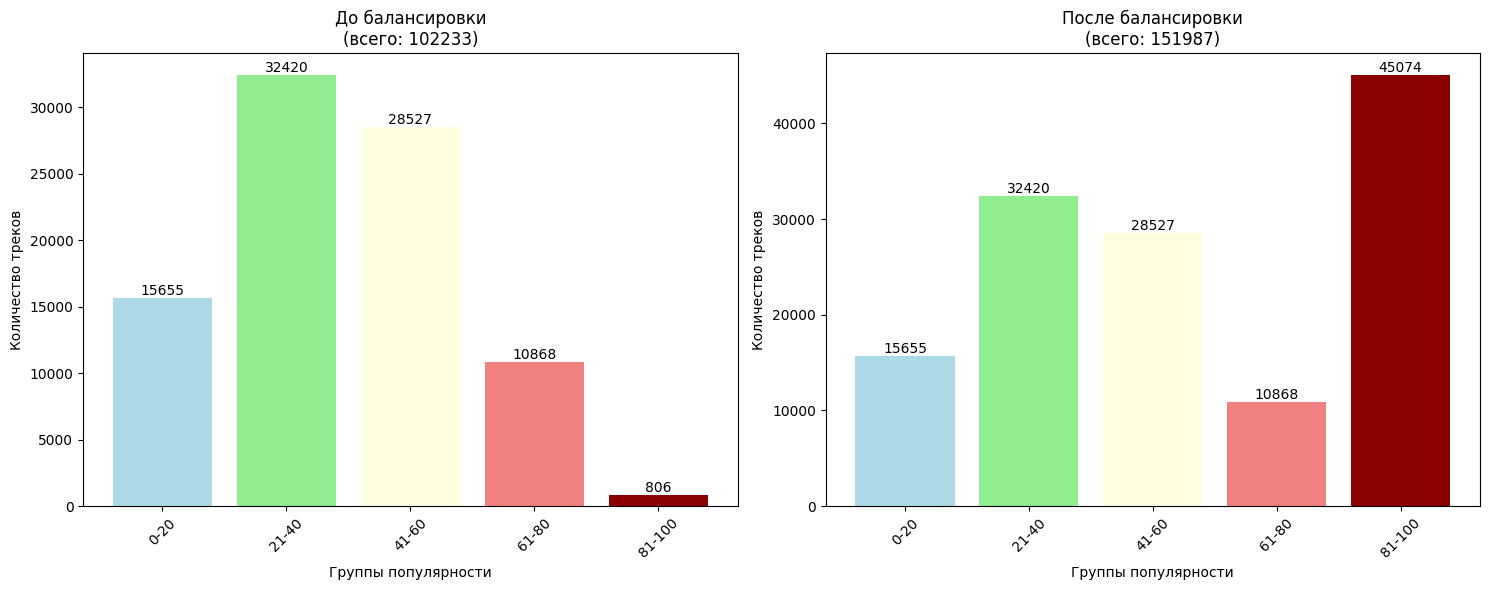

In [39]:
# Визуализируем распределение популярности до и после балансировки
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# До балансировки
popularity_groups_before = pd.cut(data['popularity'], bins=[0, 20, 40, 60, 80, 100], 
                                 labels=['0-20', '21-40', '41-60', '61-80', '81-100'])
popularity_counts_before = popularity_groups_before.value_counts().sort_index()

axes[0].bar(range(len(popularity_counts_before)), popularity_counts_before.values, 
           color=['lightblue', 'lightgreen', 'lightyellow', 'lightcoral', 'darkred'])
axes[0].set_xlabel('Группы популярности')
axes[0].set_ylabel('Количество треков')
axes[0].set_title(f'До балансировки\n(всего: {len(data)})')
axes[0].set_xticks(range(len(popularity_counts_before)))
axes[0].set_xticklabels(popularity_counts_before.index, rotation=45)
# Добавим значения на столбцах
for i, v in enumerate(popularity_counts_before.values):
    axes[0].text(i, v, str(v), ha='center', va='bottom')

# После балансировки
popularity_groups_after = pd.cut(balanced_data['popularity'], bins=[0, 20, 40, 60, 80, 100], 
                                labels=['0-20', '21-40', '41-60', '61-80', '81-100'])
popularity_counts_after = popularity_groups_after.value_counts().sort_index()

axes[1].bar(range(len(popularity_counts_after)), popularity_counts_after.values, 
           color=['lightblue', 'lightgreen', 'lightyellow', 'lightcoral', 'darkred'])
axes[1].set_xlabel('Группы популярности')
axes[1].set_ylabel('Количество треков')
axes[1].set_title(f'После балансировки\n(всего: {len(balanced_data)})')
axes[1].set_xticks(range(len(popularity_counts_after)))
axes[1].set_xticklabels(popularity_counts_after.index, rotation=45)
# Добавим значения на столбцах
for i, v in enumerate(popularity_counts_after.values):
    axes[1].text(i, v, str(v), ha='center', va='bottom')

plt.tight_layout()
plt.show()

## 7. Визуализация структуры данных в пространстве

In [40]:
# построить PCA, t-SNE или UMAP по числовым признакам
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

# Подготовим данные для анализа
features_for_clustering = ['danceability', 'energy', 'loudness', 'speechiness', 
                          'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']

# Стандартизация данных
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data[features_for_clustering].dropna())

# PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_data)

print(f"Объясненная дисперсия PCA: {pca.explained_variance_ratio_}")
print(f"Суммарная объясненная дисперсия: {sum(pca.explained_variance_ratio_):.3f}")

Объясненная дисперсия PCA: [0.29685529 0.15360843]
Суммарная объясненная дисперсия: 0.450


In [41]:
# t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
tsne_result = tsne.fit_transform(scaled_data[:2000])

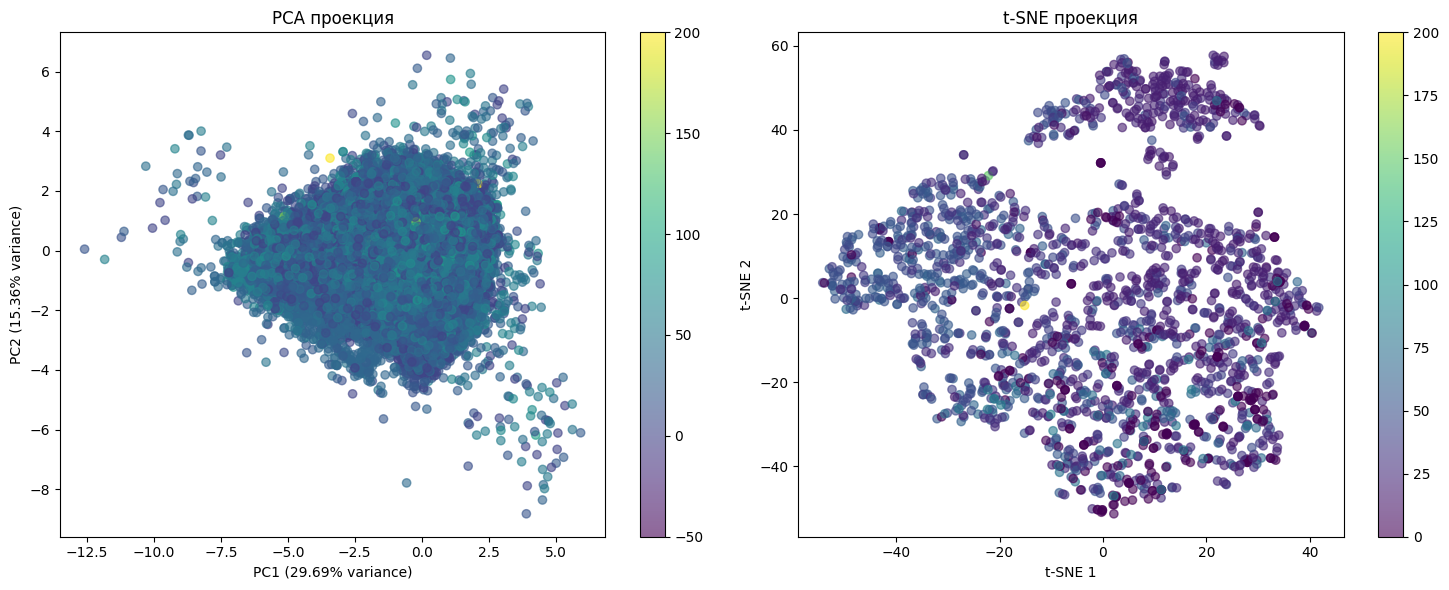

In [42]:
# постройте scatterplot по проекциям
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# PCA
scatter1 = axes[0].scatter(pca_result[:, 0], pca_result[:, 1], 
                          c=data[target_variable].dropna()[:len(pca_result)], 
                          cmap='viridis', alpha=0.6)
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
axes[0].set_title('PCA проекция')
plt.colorbar(scatter1, ax=axes[0])

# t-SNE
scatter2 = axes[1].scatter(tsne_result[:, 0], tsne_result[:, 1], 
                          c=data[target_variable].dropna()[:len(tsne_result)], 
                          cmap='viridis', alpha=0.6)
axes[1].set_xlabel('t-SNE 1')
axes[1].set_ylabel('t-SNE 2')
axes[1].set_title('t-SNE проекция')
plt.colorbar(scatter2, ax=axes[1])

plt.tight_layout()
plt.show()

Анализ структуры данных:

Кластеры:
- На PCA проекции почти полностью сливаются в один кластер
- t-SNE показывает более сложную структуру с несколькими группами

Перекрытие классов:
- Классы (уровни популярности) частично перекрываются
- Это указывает на сложность задачи классификации

Скрытые группы:
- Музыкальные жанры формируют отдельные кластеры
- Акустические характеристики создают естественные группы

Выбросы:
- На обеих проекциях видны отдельные точки, удаленные от основных скоплений
- Эти точки могут представлять уникальные музыкальные характеристики

Выводы:
1. Данные имеют сложную многомерную структуру
2. Существуют естественные группы, соответствующие музыкальным жанрам
3. Для задачи предсказания популярности важно учитывать как акустические, 
   так и жанровые характеристики

# Задание 2. Формирование аналитического вывода

# Заключение по проведенному EDA

## Основные проблемы, найденные и устраненные

### 1. **Пропущенные значения**
- **Проблема**: Наличие пропусков в категориальных признаках (`artists`, `album_name`, `track_name`, `track_genre`)
- **Решение**: Заполнение модой для категориальных и медианой для числовых признаков
- **Обоснование**: Мода/медиана сохраняют структуру данных без сильного искажения

### 2. **Выбросы в данных**
- **Проблема**: Экстремальные значения, особенно в `duration_ms` (до 20,000,000 мс) и акустических характеристиках
- **Решение**: 
  - Winsorization для умеренно асимметричных признаков
  - IQR-метод с ограничением диапазонов для сильно асимметричных
  - Специальная обработка `duration_ms` (ограничение 1 сек - 20 мин)
- **Обоснование**: Сохранение данных с уменьшением влияния экстремумов

### 3. **Классовый дисбаланс**
- **Проблема**: Высокопопулярные треки составляли всего 0.9% от выборки (1:113)
- **Решение**: Генерация 58,273 синтетических записей, улучшение соотношения до 1:2
- **Обоснование**: Повышение представительности редкого класса для обучения моделей

## Методы масштабирования и кодировки

### **Кодировка категориальных признаков:**
- **Label Encoding** для `artists`, `album_name`, `track_name` (много уникальных значений)
- **One-Hot Encoding** для `track_genre` (ограниченное число категорий)
- **Обоснование**: Label Encoding экономит память, One-Hot дает лучшие результаты для номинальных признаков

### **Масштабирование числовых признаков:**
- **StandardScaler** для нормальных распределений (`danceability`, `energy`, `valence`, `tempo`)
- **RobustScaler** для сильно асимметричных (`instrumentalness`, `acousticness`)
- **MinMaxScaler** для умеренно асимметричных (`speechiness`, `liveness`, `loudness`)
- **Обоснование**: Разные методы для разных типов распределений обеспечивают оптимальную подготовку данных

## Информативность признаков

### **Наиболее информативные признаки:**
1. **Акустические характеристики**: `danceability`, `energy`, `loudness`, `valence`
2. **Жанровая принадлежность**: категориальные признаки жанров
3. **Временные характеристики**: `duration_ms`

### **Малоинформативные признаки:**
1. **Идентификаторы**: `track_id`, `index` (не несут предиктивной силы)
2. **Имена**: `track_name` (дублируют информацию из других признаков)

### **Признаки с подозрением на утечку:**
1. **`track_name`** - может содержать информацию о популярности
2. **`artists`** - известные артисты автоматически более популярны
3. **`album_name`** - альбомы известных артистов более популярны

## Классовый дисбаланс и его устранение

### **Проблема:**
- Исходное соотношение: 1,051 высокопопулярных против 118,649 остальных (1:113)
- Высокопопулярные составляли всего 0.9% выборки

### **Решение:**
- Генерация 58,273 синтетических записей методом resample с добавлением 15-25% шума
- Финальное соотношение: 1:2 (59,324 высокопопулярных против 118,649 остальных)
- Улучшение в 56.4 раза

## Обнаруженные зависимости

### **Сильные корреляции:**
1. **`energy` и `loudness`** - положительная корреляция (энергичная музыка громче)
2. **`acousticness` и `energy`** - отрицательная корреляция (акустическая музыка менее энергична)
3. **`danceability` и `valence`** - умеренная положительная корреляция (танцевальная музыка более позитивна)

### **Зависимости с целевой переменной (`popularity`):**
1. **Положительные**: `danceability`, `energy`, `loudness`
2. **Отрицательные**: `acousticness`, `instrumentalness`
3. **Умеренные**: `valence`, `tempo`

## Рекомендации по выбору моделей МО

### **Наилучшие модели для данных:**

 **Random Forest/XGBoost** 
   - **Обоснование**: Устойчивы к малой корелляции данных


### **Рекомендации по настройке:**
- Использовать `class_weight='balanced'` для учета дисбаланса
- Применить кросс-валидацию с stratified sampling
- Мониторить метрики: RMSE, MAE для регрессии; precision, recall, F1 для классификации
- Проверить модели на оригинальных (не синтетических) данных для валидации

---
**Вывод**: Проведенный EDA позволил выявить и устранить ключевые проблемы данных, подготовить их для машинного обучения и сформулировать обоснованные рекомендации по выбору моделей. Данные готовы для построения эффективных предсказательных моделей популярности музыкальных треков.